# Customer Segmentation Analysis


In [38]:
# Import pandas library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Dataset Loading and Data Cleaning

###### The e-commerce dataset was loaded using the pandas library and inspected to understand its structure, column names, data types, number of rows, and missing values.

###### Missing or invalid values in important columns such as User ID, Product ID, Purchase Date, and Final Price were identified and removed. The Purchase Date column was converted into datetime format, while price values were converted into numeric format.

###### Duplicate records and inconsistent data types were also checked to improve data quality. This cleaning process ensures that the dataset is accurate and suitable for customer behaviour analysis and K-Means clustering.


In [39]:
# Read the CSV file
df = pd.read_csv("dataset/ecommerce_dataset_updated.csv",encoding="ISO-8859-1")

# # Show first 5 rows
# df.head()

# # Show last 5 rows
# df.tail()

# # Number of rows and columns
# df.shape

# # Show column names
# df.columns

# # Display data types
# df.dtypes

# # Show complete information
# df.info()

# # Count missing values
# df.isnull().sum()

# # Remove missing values
# df.dropna(inplace=True)

# # Count duplicate rows
# df.duplicated().sum()

# # Remove duplicate rows
# df.drop_duplicates(inplace=True)

# if "Quantity" in df.columns:
#     df["Total_Amount"] = df["Quantity"] * df["Price (Rs.)"]
#     print(df["Quantity"].head())
# else:
#     print("Quantity column was not found.")
    
# frequency = df.groupby("User_ID").size()

display(df.head())

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


# Descriptive Statistics of Customer Purchasing Behaviour

###### Descriptive statistics were calculated to understand the purchasing behaviour and value of each customer.

###### **Average Purchase Value** represents the average amount spent by a customer per purchase. **Purchase Frequency** shows the total number of purchases made by each customer. 
###### **Estimated Customer Lifetime Value** represents the total value contributed by a customer and was calculated by multiplying Average Purchase Value by Purchase Frequency.

###### These metrics help identify frequent buyers, high-spending customers, low-value customers, and customers who contribute the most revenue. They also provide important information for selecting behavioural features for customer segmentation.


In [40]:
# -------------------------------------------------
# 1. Calculate Average Purchase Value
# -------------------------------------------------
# Mean purchase amount for each customer
average_purchase_value = (
    df.groupby("User_ID")["Final_Price(Rs.)"]
    .mean()
    .reset_index(name="Average_Purchase_Value")
)

# -------------------------------------------------
# 2. Calculate Purchase Frequency
# -------------------------------------------------
# Number of purchases made by each customer
purchase_frequency = (
    df.groupby("User_ID")["Product_ID"]
    .count()
    .reset_index(name="Purchase_Frequency")
)

# -------------------------------------------------
# 3. Calculate Total Customer Spending
# -------------------------------------------------
# Total amount spent by each customer
total_spending = (
    df.groupby("User_ID")["Final_Price(Rs.)"]
    .sum()
    .reset_index(name="Total_Spending")
)

# -------------------------------------------------
# 4. Combine all customer statistics
# -------------------------------------------------
customer_stats = average_purchase_value.merge(
    purchase_frequency,
    on="User_ID"
)

customer_stats = customer_stats.merge(
    total_spending,
    on="User_ID"
)

# -------------------------------------------------
# 5. Calculate Estimated Customer Lifetime Value
# -------------------------------------------------
customer_stats["Estimated_CLV"] = (
    customer_stats["Average_Purchase_Value"]
    * customer_stats["Purchase_Frequency"]
)

# Display customer statistics
display(customer_stats.head())

# Display descriptive statistics
display(
    customer_stats[
        [
            "Average_Purchase_Value",
            "Purchase_Frequency",
            "Total_Spending",
            "Estimated_CLV"
        ]
    ].describe()
)

,User_ID,Average_Purchase_Value,Purchase_Frequency,Total_Spending,Estimated_CLV
0,001ae40d,345.93,1,345.93,345.93
1,00209791,10.32,1,10.32,10.32
2,0021e458,123.51,1,123.51,123.51
3,00333c7a,8.65,1,8.65,8.65
4,00390cf5,96.32,1,96.32,96.32


,Average_Purchase_Value,Purchase_Frequency,Total_Spending,Estimated_CLV
count,3660.000000,3660.0,3660.000000,3660.000000
mean,206.906579,1.0,206.906579,206.906579
std,122.687844,0.0,122.687844,122.687844
min,5.890000,1.0,5.890000,5.890000
25%,104.512500,1.0,104.512500,104.512500
50%,199.185000,1.0,199.185000,199.185000
75%,304.117500,1.0,304.117500,304.117500
max,496.820000,1.0,496.820000,496.820000


# Feature Selection Using RFM Analysis

###### Three important behavioural features were selected for customer clustering: Recency, Frequency, and Monetary value.

###### **Recency** represents the number of days since a customer’s most recent purchase. 
###### **Frequency** represents the total number of purchases made by the customer. 
###### **Monetary value** represents the total amount spent by the customer.

###### These features were selected because they describe how recently a customer purchased, how often they purchase, and how much they spend. The User ID was excluded because it is only an identifier and does not represent purchasing behaviour.

###### The selected RFM features were used as inputs for data standardisation and K-Means clustering.


In [41]:

# Display column names
print(df.columns)

# Convert Purchase_Date column into datetime format
df["Purchase_Date"] = pd.to_datetime(
    df["Purchase_Date"],
    errors="coerce"
)

# Remove rows where Purchase_Date could not be converted
df = df.dropna(subset=["Purchase_Date"])

# Create a reference date
# It is one day after the latest purchase date in the dataset
reference_date = df["Purchase_Date"].max() + pd.Timedelta(days=1)

print("Latest purchase date:", df["Purchase_Date"].max())
print("Reference date:", reference_date)

# Calculate RFM features for every customer
rfm = df.groupby("User_ID").agg(
    
    # Number of days since the customer's latest purchase
    Recency=(
        "Purchase_Date",
        lambda dates: (reference_date - dates.max()).days
    ),

    # Number of purchases made by the customer
    Frequency=(
        "Product_ID",
        "count"
    ),

    # Total amount spent by the customer
    Monetary=(
        "Final_Price(Rs.)",
        "sum"
    )

).reset_index()

# Display the first five customers
display(rfm.head())

# Display descriptive statistics of RFM features
display(
    rfm[["Recency", "Frequency", "Monetary"]].describe()
)

Index(['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)',
       'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date'],
      dtype='str')
Latest purchase date: 2024-12-11 00:00:00
Reference date: 2024-12-12 00:00:00


,User_ID,Recency,Frequency,Monetary
0,00333c7a,160,1,8.65
1,00390cf5,66,1,96.32
2,007d82ed,191,1,393.59
3,008ac58b,63,1,281.63
4,00b7ec0b,97,1,87.38


,Recency,Frequency,Monetary
count,1454.000000,1454.0,1454.000000
mean,168.125172,1.0,208.018569
std,106.130097,0.0,121.869918
min,1.000000,1.0,5.890000
25%,70.000000,1.0,106.157500
50%,161.000000,1.0,199.940000
75%,253.000000,1.0,306.607500
max,346.000000,1.0,492.410000


# Data Standardisation Using StandardScaler

###### Before applying K-Means clustering, the selected Recency, Frequency, and Monetary features were standardised using StandardScaler.

###### Standardisation was required because these features had different numerical ranges. For example, Monetary values could be much larger than Recency and Frequency values, which could unfairly influence the clustering results.

###### StandardScaler transformed the features to have a mean close to zero and a standard deviation close to one. This ensured that all three RFM features contributed equally to the K-Means clustering process.


In [42]:

# Select RFM features for clustering
features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

# Check for missing values
print("Missing values:")
print(features.isnull().sum())

# Remove rows containing missing values
valid_rows = features.dropna().index
features = features.loc[valid_rows].copy()
rfm = rfm.loc[valid_rows].copy()

# Create the StandardScaler object
scaler = StandardScaler()

# Standardise the RFM features
scaled_features = scaler.fit_transform(features)

# Convert scaled values into a DataFrame
scaled_features_df = pd.DataFrame(
    scaled_features,
    columns=features.columns,
    index=features.index
)

# Display the standardised data
display(scaled_features_df.head())

Missing values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


,Recency,Frequency,Monetary
0,-0.076585,0.0,-1.636476
1,-0.962595,0.0,-0.916855
2,0.215610,0.0,1.523225
3,-0.990872,0.0,0.604224
4,-0.670400,0.0,-0.990237


# Apply K-Means Clustering Using the Elbow Method

###### K-Means clustering was used to group customers based on Recency, Frequency, and Monetary value. The RFM features were standardised using StandardScaler so that all features contributed equally.
###### The Elbow Method was applied for K values from 1 to 10. The optimal number of clusters was selected where the reduction in inertia began to slow down.
###### The final K-Means model then assigned each customer to a cluster based on similar purchasing behaviour. These clusters can support customer analysis and targeted marketing strategies.

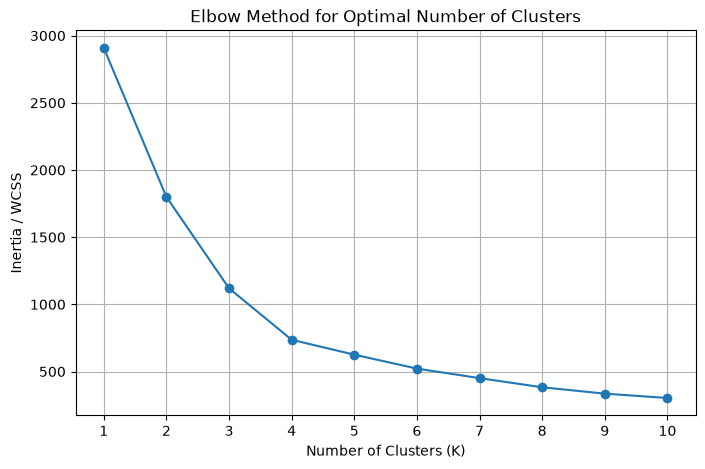

,User_ID,Recency,Frequency,Monetary,Cluster
0,00333c7a,160,1,8.65,0
1,00390cf5,66,1,96.32,0
2,007d82ed,191,1,393.59,1
3,008ac58b,63,1,281.63,3
4,00b7ec0b,97,1,87.38,0
5,00e75d81,100,1,235.23,3
6,0110e242,130,1,109.24,0
7,012757e3,35,1,247.21,3
8,01365196,218,1,190.88,2
9,016c1e77,309,1,208.77,2


Number of customers in each cluster:
Cluster
0    404
1    311
2    371
3    368
Name: count, dtype: int64


In [43]:

# --------------------------------------------------
# 1. Load the dataset
# --------------------------------------------------
df = pd.read_csv("dataset/ecommerce_dataset_updated.csv",encoding="ISO-8859-1")

# --------------------------------------------------
# 2. Clean the data
# --------------------------------------------------
df["Purchase_Date"] = pd.to_datetime(
    df["Purchase_Date"],
    errors="coerce"
)

df["Final_Price(Rs.)"] = pd.to_numeric(
    df["Final_Price(Rs.)"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "User_ID",
        "Product_ID",
        "Purchase_Date",
        "Final_Price(Rs.)"
    ]
)

# --------------------------------------------------
# 3. Create the RFM features
# --------------------------------------------------
reference_date = (
    df["Purchase_Date"].max()
    + pd.Timedelta(days=1)
)

rfm = df.groupby("User_ID").agg(
    
    Recency=(
        "Purchase_Date",
        lambda dates: (reference_date - dates.max()).days
    ),
    
    Frequency=(
        "Product_ID",
        "count"
    ),
    
    Monetary=(
        "Final_Price(Rs.)",
        "sum"
    )
    
).reset_index()

# --------------------------------------------------
# 4. Select features
# --------------------------------------------------
features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

# --------------------------------------------------
# 5. Standardise features
# --------------------------------------------------
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features_df = pd.DataFrame(
    scaled_features,
    columns=features.columns,
    index=features.index
)

# --------------------------------------------------
# 6. Elbow Method
# --------------------------------------------------
inertia_values = []
k_values = range(1, 11)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    
    kmeans.fit(scaled_features_df)
    inertia_values.append(kmeans.inertia_)

# --------------------------------------------------
# 7. Plot Elbow graph
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

# --------------------------------------------------
# 8. Apply final K-Means
# Change this value based on the Elbow graph
# --------------------------------------------------
optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    n_init=10,
    random_state=42
)

rfm["Cluster"] = final_kmeans.fit_predict(
    scaled_features_df
)

# --------------------------------------------------
# 9. Display results
# --------------------------------------------------
display(rfm.head(10))

print("Number of customers in each cluster:")

print(
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

# Customer Cluster Visualisation Using Scatter Plots

###### Scatter plots were used to visualise the customer segments created by the K-Means model. The first plot compares Recency and Frequency, while the second plot compares Frequency and Monetary value. Different colours represent different customer clusters and help identify active, loyal, high-value, occasional, and inactive customers.

['User_ID', 'Recency', 'Frequency', 'Monetary', 'Cluster']


,User_ID,Recency,Frequency,Monetary,Cluster
0,00333c7a,160,1,8.65,0
1,00390cf5,66,1,96.32,0
2,007d82ed,191,1,393.59,1
3,008ac58b,63,1,281.63,3
4,00b7ec0b,97,1,87.38,0


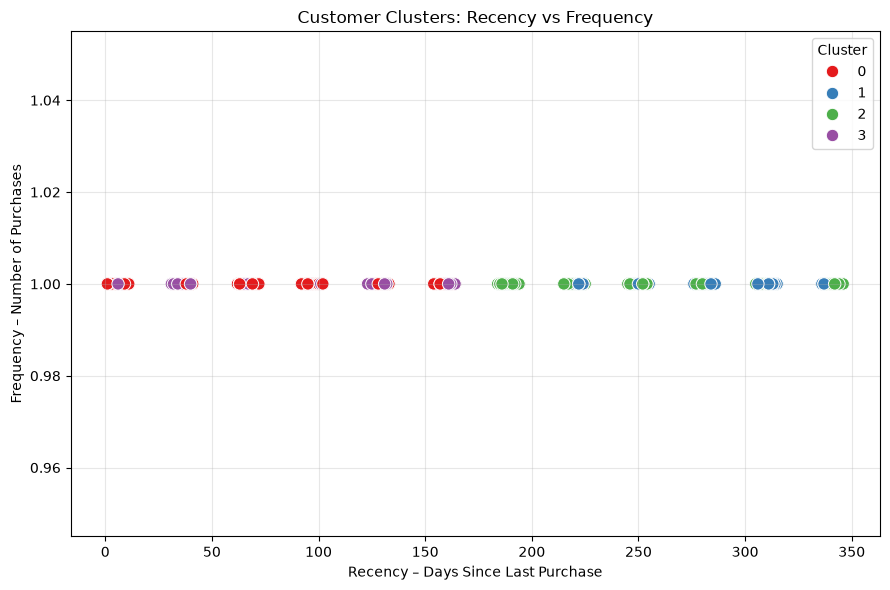

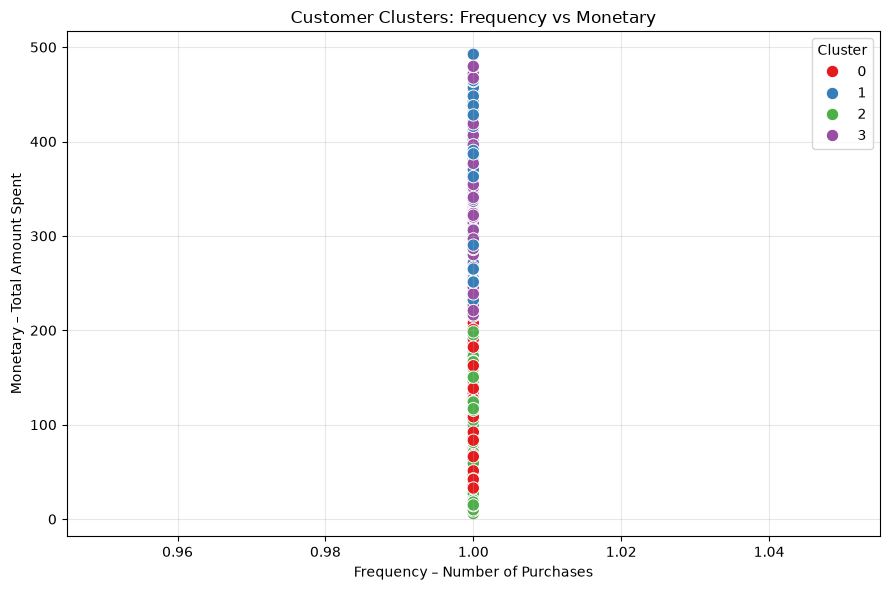

In [44]:
print(rfm.columns.tolist())
display(rfm.head())

# Verify that all required columns are available
required_columns = ["Recency", "Frequency", "Monetary", "Cluster"]

missing_columns = [
    column for column in required_columns
    if column not in rfm.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}. "
        "Run the RFM and K-Means cells first."
    )

# --------------------------------------------------
# Scatter Plot 1: Recency vs Frequency
# --------------------------------------------------
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Clusters: Recency vs Frequency")
plt.xlabel("Recency – Days Since Last Purchase")
plt.ylabel("Frequency – Number of Purchases")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Scatter Plot 2: Frequency vs Monetary
# --------------------------------------------------
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Frequency – Number of Purchases")
plt.ylabel("Monetary – Total Amount Spent")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Customer Cluster Profiling

###### The mean Recency, Frequency, and Monetary values were calculated for each cluster to understand the purchasing behaviour of customers.

###### A low Recency value indicates a recent purchase, while high Frequency and Monetary values indicate regular and high-spending customers. Based on these average values, each cluster was assigned a suitable customer type, such as Champions, Loyal Customers, Regular Customers, or Inactive Customers

In [45]:
print(rfm.columns.tolist())
display(rfm.head())

# --------------------------------------------------
# 1. Check required columns
# --------------------------------------------------
required_columns = [
    "User_ID",
    "Recency",
    "Frequency",
    "Monetary",
    "Cluster"
]

missing_columns = [
    column for column in required_columns
    if column not in rfm.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}. "
        "Create RFM features and apply K-Means first."
    )


# --------------------------------------------------
# 2. Calculate cluster mean values
# --------------------------------------------------
cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Mean_Recency=("Recency", "mean"),
        Mean_Frequency=("Frequency", "mean"),
        Mean_Monetary=("Monetary", "mean"),
        Customer_Count=("User_ID", "count")
    )
    .round(2)
    .reset_index()
)


# --------------------------------------------------
# 3. Calculate overall averages
# --------------------------------------------------
overall_recency = rfm["Recency"].mean()
overall_frequency = rfm["Frequency"].mean()
overall_monetary = rfm["Monetary"].mean()


# --------------------------------------------------
# 4. Create customer-type function
# --------------------------------------------------
def describe_customer_type(row):

    low_recency = row["Mean_Recency"] <= overall_recency
    high_frequency = row["Mean_Frequency"] >= overall_frequency
    high_monetary = row["Mean_Monetary"] >= overall_monetary

    if low_recency and high_frequency and high_monetary:
        return "Champions"

    elif low_recency and high_frequency:
        return "Loyal Customers"

    elif low_recency and not high_frequency and not high_monetary:
        return "New or Occasional Customers"

    elif not low_recency and high_monetary:
        return "At-Risk High-Value Customers"

    elif not low_recency and not high_frequency and not high_monetary:
        return "Inactive Customers"

    else:
        return "Regular Customers"


# --------------------------------------------------
# 5. Assign customer types
# --------------------------------------------------
cluster_profile["Customer_Type"] = cluster_profile.apply(
    describe_customer_type,
    axis=1
)

segment_mapping = dict(
    zip(
        cluster_profile["Cluster"],
        cluster_profile["Customer_Type"]
    )
)

rfm["Customer_Type"] = rfm["Cluster"].map(segment_mapping)


# --------------------------------------------------
# 6. Display results
# --------------------------------------------------
print("Customer cluster profile:")
display(cluster_profile)

print("Customers with segment names:")
display(rfm.head(10))

['User_ID', 'Recency', 'Frequency', 'Monetary', 'Cluster']


,User_ID,Recency,Frequency,Monetary,Cluster
0,00333c7a,160,1,8.65,0
1,00390cf5,66,1,96.32,0
2,007d82ed,191,1,393.59,1
3,008ac58b,63,1,281.63,3
4,00b7ec0b,97,1,87.38,0


Customer cluster profile:


,Cluster,Mean_Recency,Mean_Frequency,Mean_Monetary,Customer_Count,Customer_Type
0,0,77.15,1.0,107.23,404,Loyal Customers
1,1,270.06,1.0,321.51,311,At-Risk High-Value Customers
2,2,263.87,1.0,114.34,371,Regular Customers
3,3,85.34,1.0,317.20,368,Champions


Customers with segment names:


,User_ID,Recency,Frequency,Monetary,Cluster,Customer_Type
0,00333c7a,160,1,8.65,0,Loyal Customers
1,00390cf5,66,1,96.32,0,Loyal Customers
2,007d82ed,191,1,393.59,1,At-Risk High-Value Customers
3,008ac58b,63,1,281.63,3,Champions
4,00b7ec0b,97,1,87.38,0,Loyal Customers
5,00e75d81,100,1,235.23,3,Champions
6,0110e242,130,1,109.24,0,Loyal Customers
7,012757e3,35,1,247.21,3,Champions
8,01365196,218,1,190.88,2,Regular Customers
9,016c1e77,309,1,208.77,2,Regular Customers


# Number of Customers in Each Cluster

###### A bar chart was created to compare the number of customers assigned to each cluster. The height of each bar represents the total number of customers in that cluster.

###### This visualisation helps identify the largest and smallest customer segments. Understanding the size of each segment supports better marketing planning and resource allocation.

Number of customers in each cluster:


,Cluster,Customer_Count
0,0,404
1,1,311
2,2,371
3,3,368


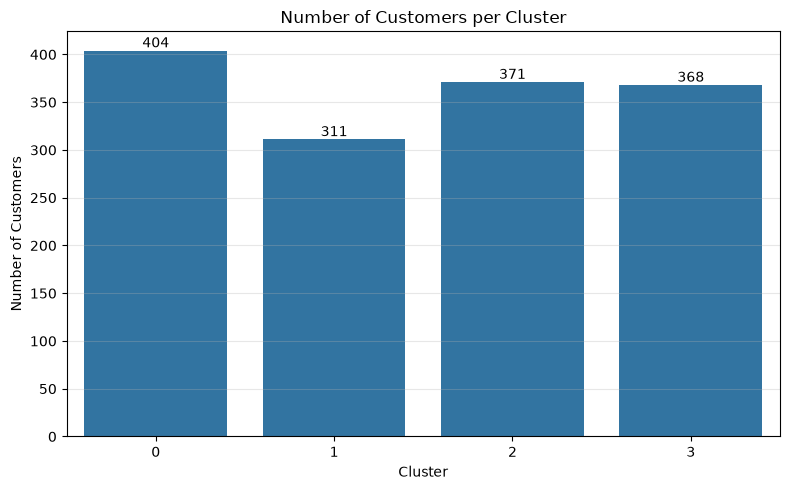

In [46]:

# --------------------------------------------------
# 1. Check whether the Cluster column exists
# --------------------------------------------------
if "Cluster" not in rfm.columns:
    raise ValueError(
        "The 'Cluster' column is missing. "
        "Apply K-Means clustering before running this code."
    )

# --------------------------------------------------
# 2. Count customers in each cluster
# --------------------------------------------------
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename the columns
cluster_counts.columns = [
    "Cluster",
    "Customer_Count"
]

# Display customer counts
print("Number of customers in each cluster:")
display(cluster_counts)

# --------------------------------------------------
# 3. Create the bar chart
# --------------------------------------------------
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=cluster_counts,
    x="Cluster",
    y="Customer_Count"
)

# Add graph title and labels
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

# Display the value above every bar
for container in ax.containers:
    ax.bar_label(container)

# Add horizontal grid lines
plt.grid(axis="y", alpha=0.3)

# Adjust spacing
plt.tight_layout()

# Display the graph
plt.show()

# Marketing Recommendations for Customer Segments

###### Marketing actions were recommended for each customer segment based on its Recency, Frequency, and Monetary behaviour.

###### High-value and loyal customers should receive rewards, exclusive offers, and early access to new products. New and occasional customers should receive welcome offers and personalised product recommendations. Inactive and at-risk customers should be targeted with re-engagement campaigns, reminders, and limited-time discounts.

###### These recommendations help the company improve customer retention, increase repeat purchases, and develop more effective targeted marketing campaigns

In [47]:
# --------------------------------------------------
# 1. Check the required columns
# --------------------------------------------------
required_columns = [
    "User_ID",
    "Recency",
    "Frequency",
    "Monetary",
    "Cluster",
    "Customer_Type"
]

missing_columns = [
    column
    for column in required_columns
    if column not in rfm.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}. "
        "Complete the customer-cluster profiling step first."
    )


# --------------------------------------------------
# 2. Define marketing actions
# --------------------------------------------------
marketing_actions = {
    "Champions": (
        "Provide VIP rewards, exclusive discounts, early product access "
        "and referral incentives."
    ),

    "Loyal Customers": (
        "Offer loyalty points, membership benefits, personalised "
        "recommendations and cross-selling offers."
    ),

    "Regular Customers": (
        "Promote product bundles, seasonal campaigns and incentives "
        "that encourage more frequent purchases."
    ),

    "New Customers": (
        "Send welcome messages, onboarding support and a discount "
        "for the next purchase."
    ),

    "New or Occasional Customers": (
        "Provide personalised product suggestions, reminders and "
        "small limited-time discounts."
    ),

    "Occasional Customers": (
        "Use purchase reminders, personalised recommendations and "
        "special offers to increase purchase frequency."
    ),

    "At-Risk High-Value Customers": (
        "Launch personalised win-back campaigns, limited-time offers "
        "and recommendations based on previous purchases."
    ),

    "Inactive Customers": (
        "Use re-engagement emails, comeback discounts and customer "
        "feedback surveys."
    )
}


# --------------------------------------------------
# 3. Add recommendation to every customer
# --------------------------------------------------
rfm["Marketing_Action"] = (
    rfm["Customer_Type"]
    .map(marketing_actions)
    .fillna("Review this segment and create a personalised campaign.")
)


# --------------------------------------------------
# 4. Create the segment-insights table
# --------------------------------------------------
segment_insights = (
    rfm.groupby("Customer_Type")
    .agg(
        Customer_Count=("User_ID", "count"),
        Mean_Recency=("Recency", "mean"),
        Mean_Frequency=("Frequency", "mean"),
        Mean_Monetary=("Monetary", "mean")
    )
    .round(2)
    .reset_index()
)

segment_insights["Recommended_Action"] = (
    segment_insights["Customer_Type"]
    .map(marketing_actions)
    .fillna("Review this segment and create a personalised campaign.")
)


# --------------------------------------------------
# 5. Display the results
# --------------------------------------------------
print("Marketing insights for each customer segment:")

display(segment_insights)

# Save segment insights as a CSV file
segment_insights.to_csv(
    "customer_segment_marketing_insights.csv",
    index=False
)

print("Marketing insights saved successfully.")

Marketing insights for each customer segment:


,Customer_Type,Customer_Count,Mean_Recency,Mean_Frequency,Mean_Monetary,Recommended_Action
0,At-Risk High-Value Customers,311,270.06,1.0,321.51,"Launch personalised win-back campaigns, limite..."
1,Champions,368,85.34,1.0,317.20,"Provide VIP rewards, exclusive discounts, earl..."
2,Loyal Customers,404,77.15,1.0,107.23,"Offer loyalty points, membership benefits, per..."
3,Regular Customers,371,263.87,1.0,114.34,"Promote product bundles, seasonal campaigns an..."


Marketing insights saved successfully.


# Conclusion

##### This project successfully segmented e-commerce customers using RFM analysis and K-Means clustering. The dataset was cleaned, important customer metrics were calculated, and Recency, Frequency, and Monetary features were standardised before clustering.

##### The Elbow Method was used to select the optimal number of clusters. Scatter plots and cluster profiles helped identify customer groups such as Champions, Loyal Customers, Regular Customers, At-Risk Customers, and Inactive Customers.

##### Suitable marketing actions were recommended for each segment, including loyalty rewards, personalised offers, welcome campaigns, and re-engagement strategies. Overall, the analysis helps the company improve customer retention, increase repeat purchases, and make better marketing decisions.
